# Adjust isotope ratio during fitting


In [1]:
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline

import MATS

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")


HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

## Define Spectrum Instances

In this example, we have a petrogenic CO2 gas sample.  


In [2]:
from MATS.linelistdata import linelistdata
import MATS.hapi as hapi

In [3]:
#Generic Fit Parameters
wave_range = 1.5 #range outside of experimental x-range to simulate
IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
Fit_Intensity = 1e-23 #intensities must be above this value for the line to be fit

wave_min = 6355
wave_max = 6365
wave_space = 0.01

PARAM_LINELIST = linelistdata['CO2_30012_Rbranch_MATS']

abundance_ratio_petrogenic = {2:{1: 1.000336343, #These isotopic abundances are only for demonstration purposes.  
                             2: 0.969999168, 
                             3: 1.000335439, 
                             4:1.000328343, 
                             5: 0.969903889, 
                             6: 0.968931144, 
                             7: 0.998155308, 
                             8:0.998777008 }}

abundance_ratio_HT= {2:{1: 1, #These isotopic abundances are only for demonstration purposes.  
                             2: 1, 
                             3: 1, 
                             4:1, 
                             5: 1, 
                             6:1, 
                             7: 1, 
                             8:1,  }}

spec_1 = MATS.simulate_spectrum(PARAM_LINELIST, 
                        wave_min=wave_min, wave_max= wave_max, wave_space=wave_space, 
                        pressure = 0.1, molefraction = {2:400e-6}, natural_abundance = False, abundance_ratio_MI = abundance_ratio_petrogenic, sim_window = wave_range)

spec_2 = MATS.simulate_spectrum(PARAM_LINELIST, 
                        wave_min=wave_min, wave_max= wave_max, wave_space=wave_space, 
                        pressure = 0.25, molefraction = {2:400e-6}, natural_abundance = False, abundance_ratio_MI = abundance_ratio_petrogenic, sim_window = wave_range)

spec_3 = MATS.simulate_spectrum(PARAM_LINELIST, 
                        wave_min=wave_min, wave_max= wave_max, wave_space=wave_space, 
                        pressure = 0.5, molefraction = {2:400e-6}, natural_abundance = False, abundance_ratio_MI = abundance_ratio_petrogenic, sim_window = wave_range)


spec_4 = MATS.simulate_spectrum(PARAM_LINELIST, 
                        wave_min=wave_min, wave_max= wave_max, wave_space=wave_space, 
                        pressure = 1, molefraction = {2:400e-6}, natural_abundance = False, abundance_ratio_MI = abundance_ratio_petrogenic, sim_window = wave_range)


spec_1.abundance_ratio_MI = abundance_ratio_HT
spec_2.abundance_ratio_MI = abundance_ratio_HT
spec_3.abundance_ratio_MI = abundance_ratio_HT
spec_4.abundance_ratio_MI = abundance_ratio_HT

In [4]:
#Generate Baseline Parameter list based on number of etalons in spectra definitions and baseline order
SPECTRA = MATS.Dataset([spec_1,spec_2, spec_3, spec_4 ], 'Abundance Floating', PARAM_LINELIST)
BASE_LINELIST = SPECTRA.generate_baseline_paramlist()

FITPARAMS = MATS.Generate_FitParam_File(SPECTRA, PARAM_LINELIST, BASE_LINELIST, lineprofile = 'mHTP', linemixing = True, 
                                          fit_intensity = Fit_Intensity, threshold_intensity = IntensityThreshold, sim_window = wave_range,
                                          nu_constrain = True, sw_constrain = True, gamma0_constrain = True, delta0_constrain = True, 
                                           aw_constrain = True, as_constrain = True, 
                                           nuVC_constrain = True, eta_constrain =True, linemixing_constrain = True)

FITPARAMS.generate_fit_param_linelist_from_linelist()
FITPARAMS.generate_fit_baseline_linelist(vary_baseline = False, vary_molefraction = {2:True}, vary_pressure = False, vary_temperature = False, vary_xshift = False)


,Segment Number,Pressure,Pressure_err,Pressure_vary,Temperature,Temperature_err,Temperature_vary,x_shift,x_shift_err,x_shift_vary,...,abundance_ratio_CO2_5_vary,abundance_ratio_CO2_6,abundance_ratio_CO2_6_err,abundance_ratio_CO2_6_vary,abundance_ratio_CO2_7,abundance_ratio_CO2_7_err,abundance_ratio_CO2_7_vary,baseline_a,baseline_a_err,baseline_a_vary
Spectrum Number,,,,,,,,,,,,,,,,,,,,,
1,1,0.10,0.0,False,296.0,0.0,False,0.0,0.0,False,...,False,1,0.0,False,1,0.0,False,0.0,0.0,False
2,1,0.25,0.0,False,296.0,0.0,False,0.0,0.0,False,...,False,1,0.0,False,1,0.0,False,0.0,0.0,False
3,1,0.50,0.0,False,296.0,0.0,False,0.0,0.0,False,...,False,1,0.0,False,1,0.0,False,0.0,0.0,False
4,1,1.00,0.0,False,296.0,0.0,False,0.0,0.0,False,...,False,1,0.0,False,1,0.0,False,0.0,0.0,False


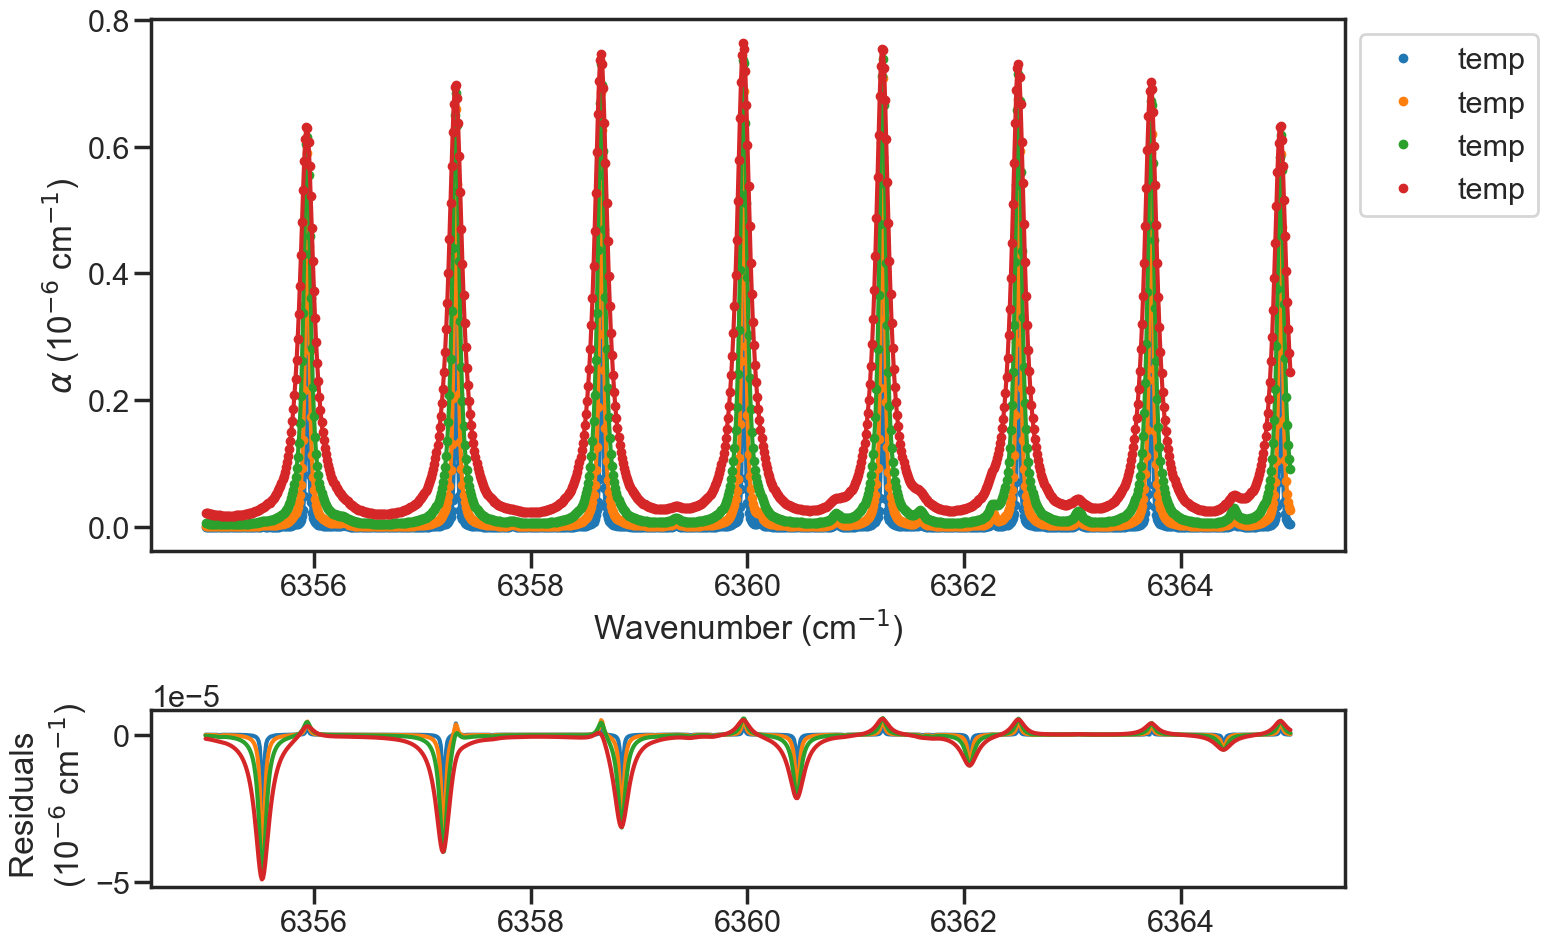

C:\Users\ema3\miniforge3\Lib\site-packages\lmfit\printfuncs.py:393: RuntimeWarning: invalid value encountered in scalar divide
  spercent = f'({abs(par.stderr/par.value):.2%})'


name,value,standard error,relative error,initial value,min,max,vary,expression
Pressure_1_1,0.10000000,0.00000000,(0.00%),0.1,-inf,inf,False,
Temperature_1_1,296.000000,0.00000000,(0.00%),296.0,-inf,inf,False,
x_shift_1_1,0.00000000,0.00000000,(nan%),0.0,-inf,inf,False,
molefraction_CO2_1_1,4.0013e-04,2.4892e-10,(0.00%),0.0004,-inf,inf,True,
abundance_ratio_CO2_1_1_1,1.00000000,0.00000000,(0.00%),1.0,-inf,inf,False,
abundance_ratio_CO2_2_1_1,1.00000000,0.00000000,(0.00%),1.0,-inf,inf,False,
abundance_ratio_CO2_3_1_1,1.00000000,0.00000000,(0.00%),1.0,-inf,inf,False,
abundance_ratio_CO2_4_1_1,1.00000000,0.00000000,(0.00%),1.0,-inf,inf,False,
abundance_ratio_CO2_5_1_1,1.00000000,0.00000000,(0.00%),1.0,-inf,inf,False,
abundance_ratio_CO2_6_1_1,1.00000000,0.00000000,(0.00%),1.0,-inf,inf,False,


In [5]:
fit_data = MATS.Fit_DataSet(SPECTRA,'Baseline_LineList', 'Parameter_LineList', minimum_parameter_fit_intensity = Fit_Intensity)
params = fit_data.generate_params()
params = fit_data.constrain_baseline_params(params, 'molefraction_CO2', 'all', vary = True)

result = fit_data.fit_data(params, wing_cutoff = 25)



fit_data.residual_analysis(result, indv_resid_plot=False)
fit_data.update_params(result)
SPECTRA.generate_summary_file(save_file = True)
SPECTRA.plot_model_residuals()


result.params


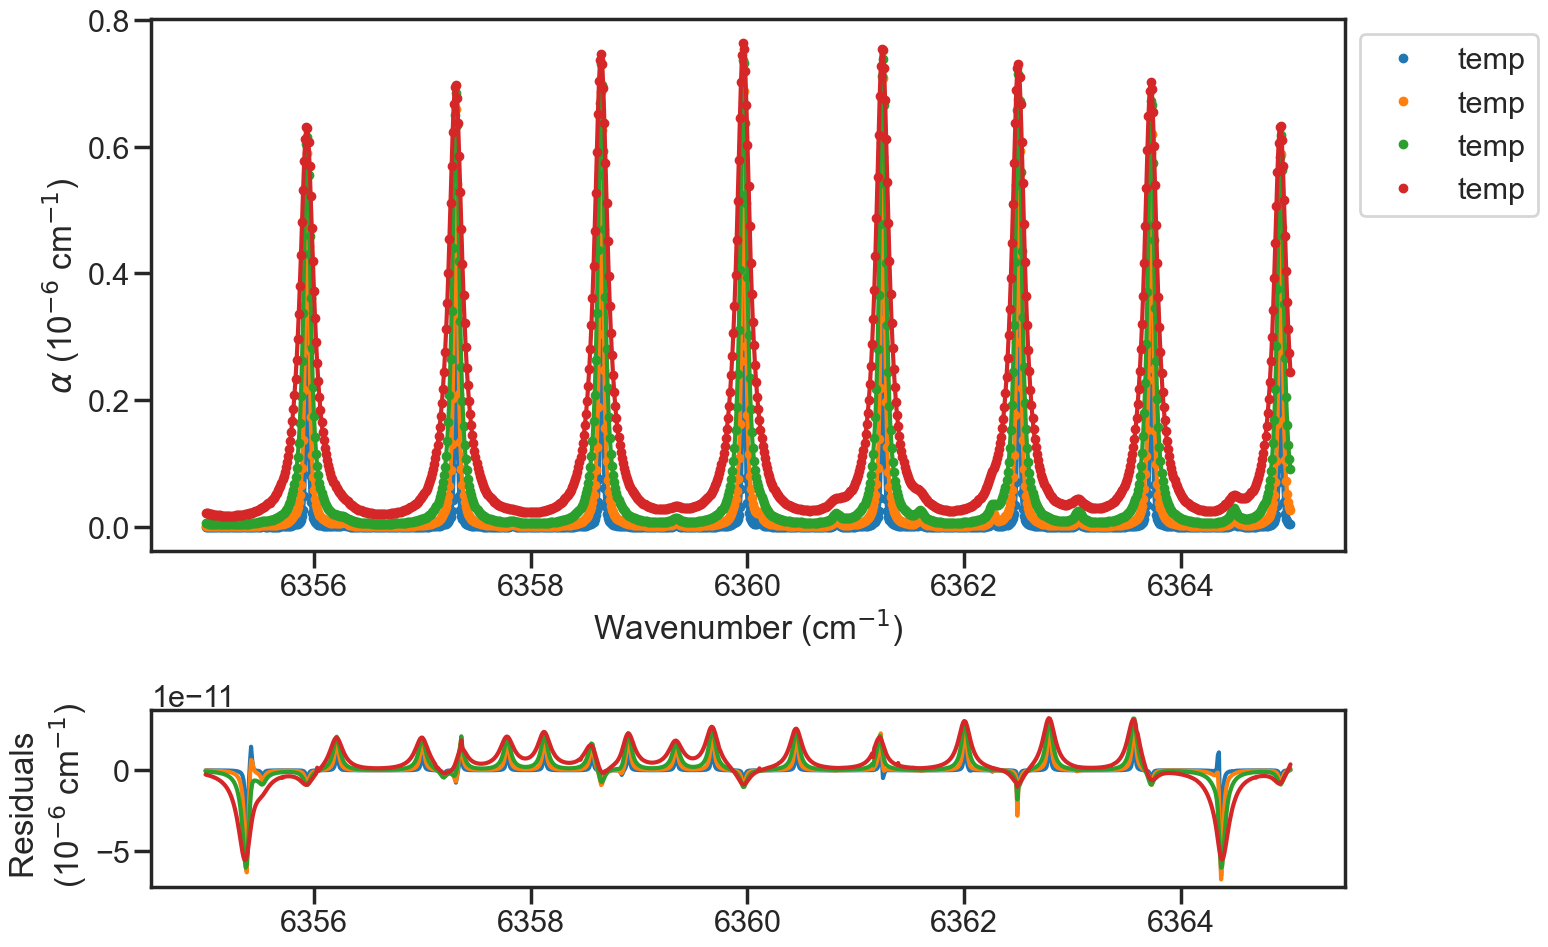

C:\Users\ema3\miniforge3\Lib\site-packages\lmfit\printfuncs.py:393: RuntimeWarning: invalid value encountered in scalar divide
  spercent = f'({abs(par.stderr/par.value):.2%})'


name,value,standard error,relative error,initial value,min,max,vary,expression
Pressure_1_1,0.10000000,0.00000000,(0.00%),0.1,-inf,inf,False,
Temperature_1_1,296.000000,0.00000000,(0.00%),296.0,-inf,inf,False,
x_shift_1_1,0.00000000,0.00000000,(nan%),0.0,-inf,inf,False,
molefraction_CO2_1_1,4.0000e-04,0.00000000,(0.00%),0.0004,-inf,inf,False,
abundance_ratio_CO2_1_1_1,1.00033634,1.0031e-12,(0.00%),1.0,0.50000000,1.50000000,True,
abundance_ratio_CO2_2_1_1,0.96999917,7.5763e-10,(0.00%),1.0,0.50000000,1.50000000,True,
abundance_ratio_CO2_3_1_1,1.00000000,0.00000000,(0.00%),1.0,0.50000000,1.50000000,False,
abundance_ratio_CO2_4_1_1,1.00000000,0.00000000,(0.00%),1.0,0.50000000,1.50000000,False,
abundance_ratio_CO2_5_1_1,1.00000000,0.00000000,(0.00%),1.0,0.50000000,1.50000000,False,
abundance_ratio_CO2_6_1_1,1.00000000,0.00000000,(0.00%),1.0,0.50000000,1.50000000,False,


In [6]:
fit_data = MATS.Fit_DataSet(SPECTRA,'Baseline_LineList', 'Parameter_LineList', minimum_parameter_fit_intensity = Fit_Intensity, 
                           abundance_ratio_bounds = [0.5, 1.5],)
params = fit_data.generate_params()

params = fit_data.constrain_baseline_params(params, 'abundance_ratio_CO2_1', 'all', vary = True)
params = fit_data.constrain_baseline_params(params, 'abundance_ratio_CO2_2', 'all', vary = True)

for param in params:
    if 'molefraction_CO2' in param:
        params[param].set(vary = False, value = 400e-6)
        
     
result = fit_data.fit_data(params, wing_cutoff = 25)
fit_data.residual_analysis(result, indv_resid_plot=False)
fit_data.update_params(result)
SPECTRA.generate_summary_file(save_file = True)
SPECTRA.plot_model_residuals()

result.params


